In [1]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import date

from BGN_LNG.Pricers.cancelation_option import NWEUnderlyingSimulator
from BGN_LNG.Utils.utils_maths import truncated_normal_sample, jump_rv

from BGN_LNG.Utils.utils_spark import fetch_cargo_prices, fetch_ffa_prices, fetch_ffa_prices_for_month_only, fetch_freight_prices, get_access_token, retrieve_credentials



In [2]:
client_id, client_secret = retrieve_credentials(file_path="client_credentials.csv")

# Authenticate:
access_token = get_access_token(client_id, client_secret)

>>>> Found credentials!
>>>> Client_id=d0953****, client_secret=601d8****
>>>> Successfully fetched an access token eyJhb****, valid 604799 seconds.


In [21]:
def get_modelled_dist_from_params(lb, up, avg, sigma, pj, muj, sigmaj, n=1000000):
    basic_nwe = truncated_normal_sample(n, lb, up, avg, sigma=sigma)
    jump_nwe = jump_rv(n, p=pj, mu=muj, sigma=sigmaj)

    return basic_nwe + jump_nwe

def plot_x_y_histograms(x, xlabel, y, ylabel, title_plot):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Choose bins: a fixed int or a rule like 'auto' / 'fd' (Freedman–Diaconis)
    bins = 40  # or an integer like 30

    # Plot overlapped histograms with transparency (alpha)
    ax.hist(x, bins=bins, density=True, alpha=0.6, color='#1f77b4', label=xlabel)
    ax.hist(y, bins=bins, density=True, alpha=0.45, color='#ff7f0e', label=ylabel)


    ax.set_title('Overlapped Histograms: ' + title_plot)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()

In [22]:
# HISTORICAL HISTOGRAM OF NWE
from datetime import date

month = "M+2"  # Change this depending on tenor
hist_df = fetch_cargo_prices(access_token, 'sparknwe', 30*30, month="M+2")
latest_price_df = fetch_cargo_prices(access_token, 'sparknwe', 2, month="M+2", latest_only=True)
latest_price = latest_price_df.Price.values[0]

full_df_nona = hist_df.dropna()
full_df_nona.set_index("Release Date", inplace=True)
full_df_nona.index = [d.date() for d in full_df_nona.index]
full_df_nona.index.name = None
# full_df_nona.plot(title="NWE full range")
# plt.show()
hist_df = full_df_nona[full_df_nona.index > date(2024, 1, 1)]
# last_2years.plot(title="NWE last 2 years")
# plt.show()

# hist_df = fetch_freight_prices(access_token, "spark30s", 30*30, my_vessel='174-2stroke')
# hist_df = fetch_ffa_prices(access_token, "spark30ffa-monthly", 30*30)



/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/latest/
>>>> Get latest price release for sparknwe-b-fo
release date = 2025-12-18


Latest price for M+2 on NWE is -0.5150
Average of modelled dist. on NWE is -0.4751


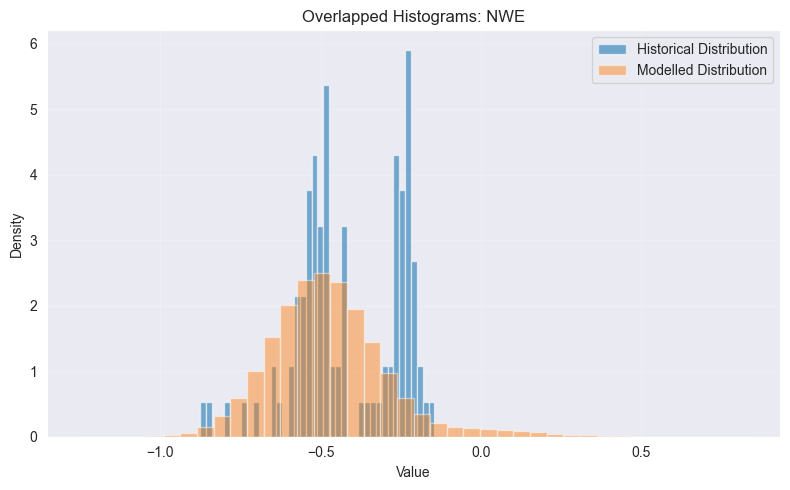

In [23]:
x = hist_df["Price"]
lb_nwe=-1.5
up_nwe=0.5
avg_nwe=-0.5
sigma_nwe=0.15
pj_nwe=0.05
muj_nwe=0.5
sigmaj_nwe=0.1

y = get_modelled_dist_from_params(
    lb=lb_nwe,
    up=up_nwe,
    avg=avg_nwe,
    sigma=sigma_nwe,
    pj=pj_nwe,
    muj=muj_nwe,
    sigmaj=sigmaj_nwe,
    n=1000000
)
y_avg = y.mean()

plot_x_y_histograms(x, "Historical Distribution", y, "Modelled Distribution", title_plot="NWE")
print(f"Latest price for {month} on NWE is {latest_price:.4f}")
print(f"Average of modelled dist. on NWE is {y_avg:.4f}")



In [24]:
# HISTORICAL HISTOGRAM OF FREIGHT
from datetime import date

month_tenor = "Aug-2026"
hist_df = fetch_ffa_prices_for_month_only(access_token, "spark30ffa-monthly", 30*30, month_tenor=month_tenor)
latest_ffa_price = hist_df.iloc[0].Spark

# hist_df = fetch_ffa_prices(access_token, "spark30ffa-monthly", 30*30)


spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900


Latest price for Aug-2026 on Spark is 36500.0000
Average of modelled dist. on Spark is 37563.9916


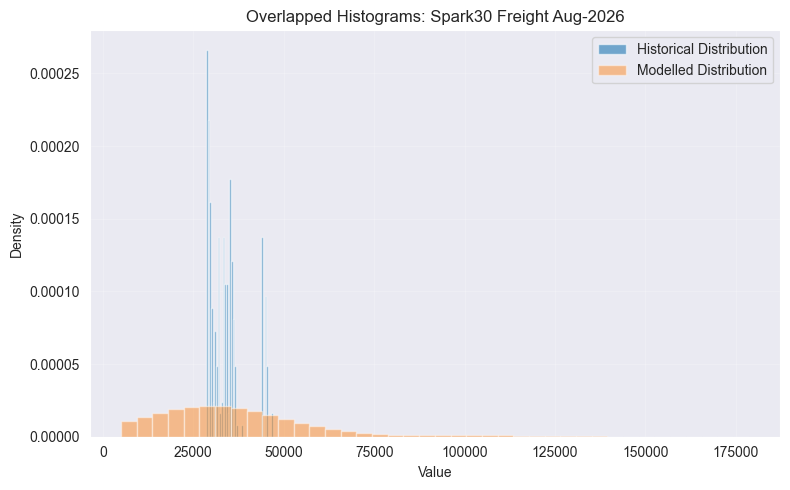

In [28]:
x = hist_df["Spark"]

lb_spark=5000
up_spark=100000
avg_spark=30000
sigma_spark=20000
pj_spark=0.05
muj_spark=70000
sigmaj_spark=5000

y = get_modelled_dist_from_params(
    lb=lb_spark,
    up=up_spark,
    avg=avg_spark,
    sigma=sigma_spark,
    pj=pj_spark,
    muj=muj_spark,
    sigmaj=sigmaj_spark,
    n=1000000
)
y_avg = y.mean()

plot_x_y_histograms(x, "Historical Distribution", y, "Modelled Distribution", title_plot=f"Spark30 Freight {month_tenor}")
print(f"Latest price for {month_tenor} on Spark is {latest_ffa_price:.4f}")
print(f"Average of modelled dist. on Spark is {y_avg:.4f}")


In [3]:
from BGN_LNG.Pricers.cancelation_option import NWEUnderlyingSimulator, FreightUnderlyingSimulator, LNGOptionPricer

latest_price_df = fetch_cargo_prices(access_token, 'sparknwe', 2, month="M+2", latest_only=True)
latest_price = latest_price_df.Price.values[0]

nwe_simulator = NWEUnderlyingSimulator(
    normal_lb=-1.5,
    normal_ub=0.5,
    normal_avg=-0.5,
    normal_sigma=0.15,
    jump_probability=0.05,
    jump_avg=0.5,
    jump_sigma=0.1,
    current_price=latest_price,
    n=1000000
)

month_tenor = "Aug-2026"
hist_df = fetch_ffa_prices_for_month_only(access_token, "spark30ffa-monthly", 2, month_tenor=month_tenor)
latest_ffa_price = hist_df.iloc[0].Spark

freight_simulator = FreightUnderlyingSimulator(
    normal_lb=5000,
    normal_ub=100000,
    normal_avg=30000,
    normal_sigma=20000,
    jump_probability=0.05,
    jump_avg=70000,
    jump_sigma=5000,
    current_price=latest_ffa_price,
    n=1000000
)


egypt_spread = 0.8
financing_cost = 0.05 * 9  # The 9 should be the corresponding price of TTF at that month
days_to_egypt = 7
purchase_mmbtu = 3500000
selling_net_spred = egypt_spread - financing_cost

lngPricer = LNGOptionPricer(
    nwe_simulator=nwe_simulator,
    freight_simulator=freight_simulator,
    bought_mmbtu=purchase_mmbtu,
    boil_off_rate=0.0085,
    route_days=days_to_egypt,
    selling_net_spread=selling_net_spred
)

option_value = lngPricer.price_option()


Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/latest/
>>>> Get latest price release for sparknwe-b-fo
release date = 2025-12-18
spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=2
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=2


In [5]:
option_value

OptionValue: 0.750287, ForwardValue: 0.749992, OptionIntrinsic: 0.792000, ForwardIntrinsic: 0.792000

-0.39965112025915994


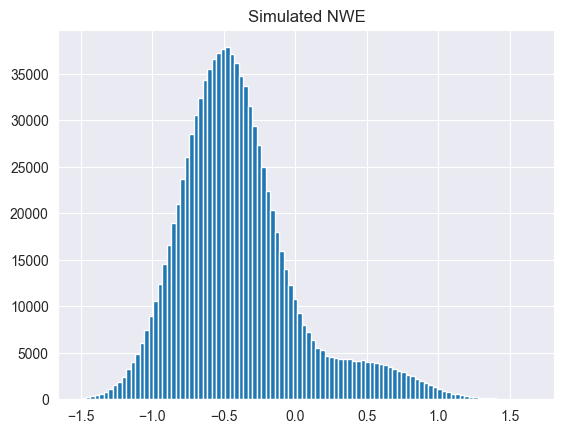

37556.43569741036


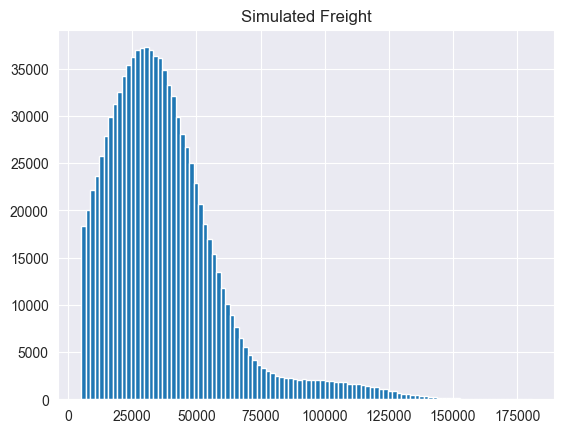

Option payoff: 0.6929
Option std: 0.3600
Forward payoff: 0.6645
Forward std: 0.4274


Text(0.5, 1.0, 'Forward Payoff histogram')

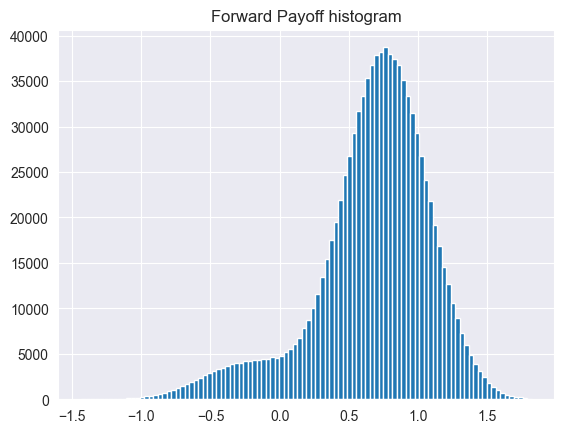

In [8]:
n = 1000000
basic_nwe = truncated_normal_sample(n, -1.5, 0.5, -0.5, sigma=0.3)
jump_nwe = jump_rv(n, p=0.1, mu=1.0, sigma=0.1)

x = basic_nwe + jump_nwe
print(x.mean())
# plt.hist(x, bins=100);
# plt.title("Simulated NWE")
# plt.show()


basic_freight = truncated_normal_sample(n, 5000, 100000, 30000, sigma=20000)
jump_freight = jump_rv(n, p=0.05, mu=70000, sigma=5000)

freight = basic_freight + jump_freight
print(freight.mean())
# plt.hist(freight, bins=100);
# plt.title("Simulated Freight")
# plt.show()


egypt_spread = 0.8
financing_cost = 0.05 * 9  # The 9 should be the corresponding price of TTF at that month
days_to_egypt = 7
purchase_mmbtu = 3500000
sold_mmbtu = 3400000
freight_usd = freight * days_to_egypt


forward_payoff = (-purchase_mmbtu * x + sold_mmbtu * egypt_spread - freight_usd - financing_cost * sold_mmbtu) / purchase_mmbtu

option_payoff = np.maximum(forward_payoff, 0.0)

print(f"Option payoff: {option_payoff.mean():.4f}")
print(f"Option std: {option_payoff.std():.4f}")
print(f"Forward payoff: {forward_payoff.mean():.4f}")
print(f"Forward std: {forward_payoff.std():.4f}")

plt.hist(forward_payoff, bins=100);
plt.title("Forward Payoff histogram")